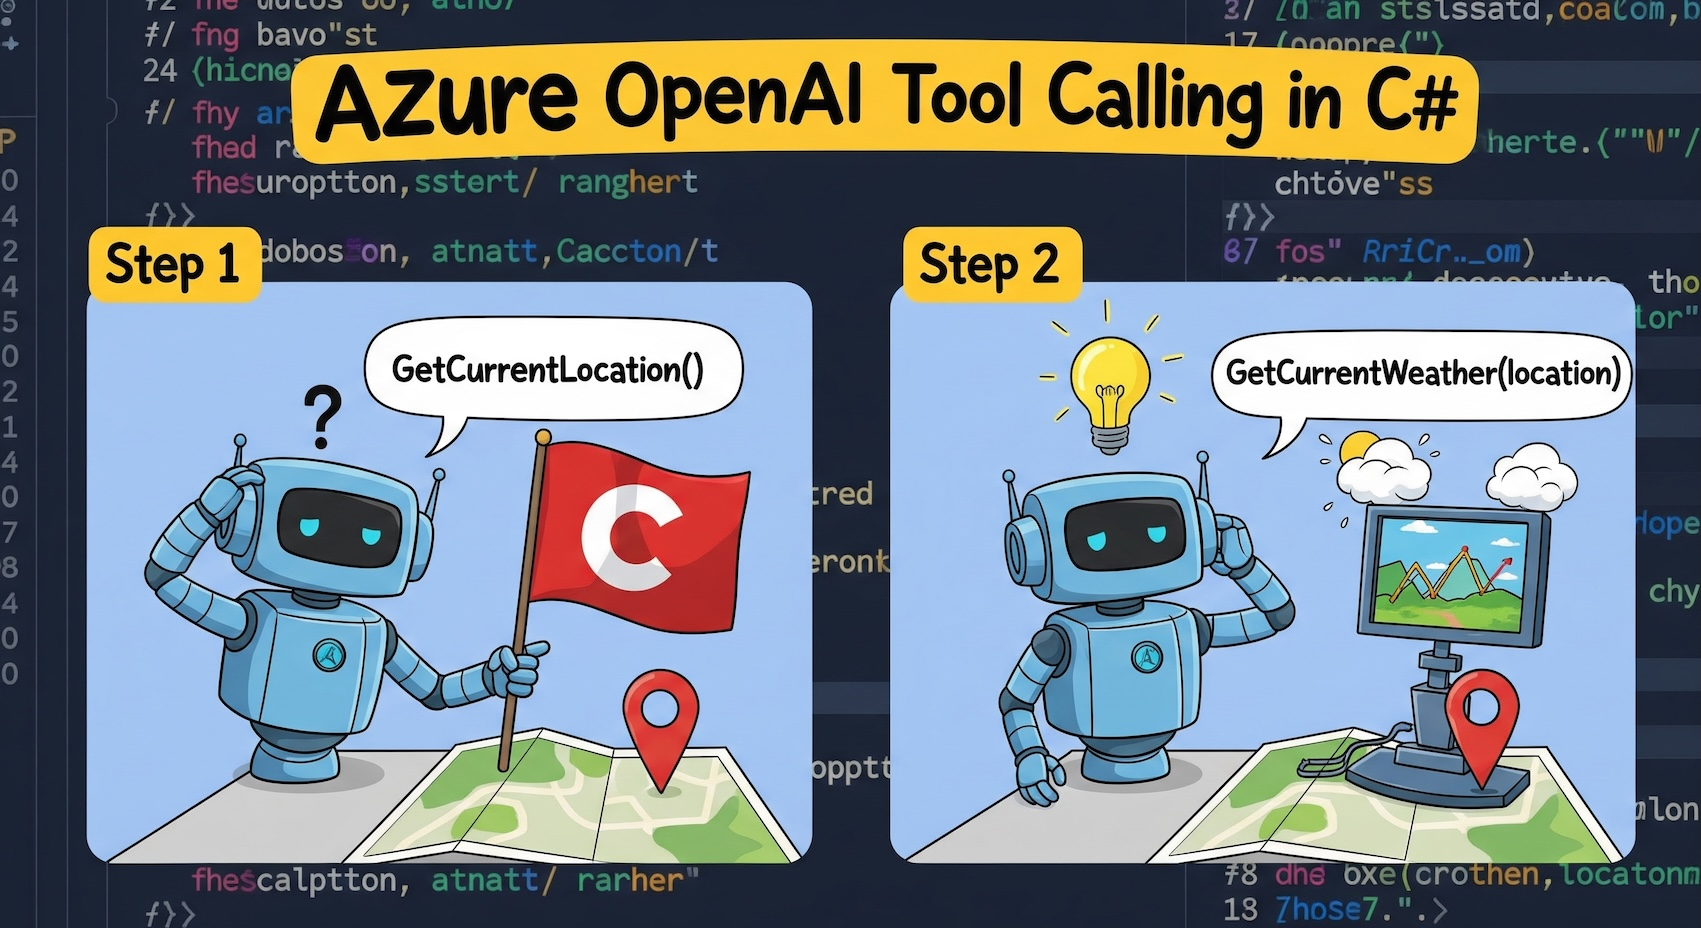

# Azure OpenAI Tool Calling in C# with Google Colab

This notebook demonstrates how to utilize Azure OpenAI's tool calling capabilities within a C# environment hosted on Google Colab. It showcases the integration of the .NET Interactive Jupyter kernel to execute C# code directly within the notebook.

## Setup

The initial steps involve:

- Installing the .NET SDK and the `dotnet-interactive` Jupyter kernel.
- Setting up a proxy kernel to handle communication between the Colab environment and the C# kernel.
- Loading environment variables from a `.env` file (ensure you upload your `.env` file to the Colab files tab).
- Initializing the `AzureOpenAIClient` and `ChatClient` using your Azure OpenAI credentials.

## Tool Calling Example

The notebook defines two simple functions as tools:

- `GetCurrentLocation()`: Returns a hardcoded location ("San Francisco").
- `GetCurrentWeather(string location, string unit)`: Returns a random weather value for a given location and unit.

These functions are then defined as `ChatTool` objects with descriptions and parameter schemas for the language model to understand.

## Handling Tool Calls

A helper function `GetToolCallContent` is provided to process the arguments from a tool call and execute the corresponding C# function, returning the result.

## Chat Completion with Tool Calling

The notebook demonstrates two approaches for handling chat completions involving tool calls:

1.  **Single-turn conversation (`startConversation`)**: This function sends the initial user message, processes any tool calls returned by the model, adds the tool results to the conversation, and then sends a final message to the model to get a user-facing response. This is suitable for simpler interactions where a single tool call or a series of tool calls can resolve the user's request in one turn.

2.  **Multi-turn conversation (`startMultiConversation`)**: This function handles scenarios where the model might require multiple turns to gather information or perform sequential tool calls before providing a final response. It uses a loop that continues as long as the model indicates the need for further actions (e.g., by returning tool calls).

## Examples

The notebook includes examples demonstrating:

- Requesting the weather for multiple locations in a single turn.
- Handling cases where the model needs more information from the user before making a tool call.
- A multi-turn conversation where the model first calls `GetCurrentLocation` and then uses that information to call `GetCurrentWeather`.

This notebook provides a solid foundation for building more complex applications that leverage Azure OpenAI's tool calling feature within a C# environment in Google Colab.

In [ ]:
#@title Prepare Google Colab for C# Kernel

# Install dotnet

!sudo apt-get update -qq &> /dev/null
!sudo apt-get install -y dotnet-sdk-7.0 -qq &> /dev/null

# Install jupyter kernel

!dotnet tool install --tool-path /usr/bin --version 1.0.360602 Microsoft.dotnet-interactive &> /dev/null
!dotnet interactive jupyter install &> /dev/null

# Create proxy file

with open("ipc_proxy_kernel.py", "w") as f:
    f.write("""import zmq;
import json;
import argparse;
from threading import Thread;
from traitlets.traitlets import Type;
from jupyter_client import KernelClient;
from jupyter_client.session import Session;
from jupyter_client.channels import HBChannel;
from jupyter_client.manager import KernelManager;

parser = argparse.ArgumentParser();
parser.add_argument("connection_file");
parser.add_argument("--kernel", type = str, required = True);
args = parser.parse_args();

# parse connection file details
with open(args.connection_file, "r") as connection_file:
    connection_file_contents = json.load(connection_file);
    transport = str(connection_file_contents["transport"]);
    ip = str(connection_file_contents["ip"]);
    shell_port = int(connection_file_contents["shell_port"]);
    stdin_port = int(connection_file_contents["stdin_port"]);
    control_port = int(connection_file_contents["control_port"]);
    iopub_port = int(connection_file_contents["iopub_port"]);
    hb_port = int(connection_file_contents["hb_port"]);
    signature_scheme = str(connection_file_contents["signature_scheme"]);
    key = str(connection_file_contents["key"]).encode();
# channel | kernel_type | client_type
# shell   | ROUTER      | DEALER
# stdin   | ROUTER      | DEALER
# ctrl    | ROUTER      | DEALER
# iopub   | PUB         | SUB
# hb      | REP         | REQ
zmq_context = zmq.Context()

def create_and_bind_socket(port: int, socket_type: int):
    if(port <= 0):
        raise ValueError(f"Invalid port: {port}");
    if(transport == "tcp"):
        addr = f"tcp://{ip}:{port}";
    elif(transport == "ipc"):
        addr = f"ipc://{ip}-{port}";
    else:
        raise ValueError(f"Unknown transport: {transport}");
    socket: zmq.Socket = zmq_context.socket(socket_type);
    socket.linger = 1000; # ipykernel does this
    socket.bind(addr);
    return socket;

shell_socket = create_and_bind_socket(shell_port, zmq.ROUTER);
stdin_socket = create_and_bind_socket(stdin_port, zmq.ROUTER);
control_socket = create_and_bind_socket(control_port, zmq.ROUTER);
iopub_socket = create_and_bind_socket(iopub_port, zmq.PUB);
hb_socket = create_and_bind_socket(hb_port, zmq.REP);
# Proxy and the real kernel have their own heartbeats. (shoutout to ipykernel
# for this neat little heartbeat implementation)
Thread(target = zmq.device, args = (zmq.QUEUE, hb_socket, hb_socket)).start();

def ZMQProxyChannel_factory(proxy_server_socket: zmq.Socket):
    class ZMQProxyChannel(object):
        kernel_client_socket: zmq.Socket = None;
        session: Session = None;

        def __init__(self, socket: zmq.Socket, session: Session, _ = None):
            super().__init__();
            self.kernel_client_socket = socket;
            self.session = session;

        def start(self):
            # Very convenient zmq device here, proxy will handle the actual zmq
            # proxying on each of our connected sockets (other than heartbeat).
            # It blocks while they are connected so stick it in a thread.
            Thread(
                target = zmq.proxy,
                args = (proxy_server_socket, self.kernel_client_socket)
            ).start();

        def stop(self):
            if(self.kernel_client_socket is not None):
                try:
                    self.kernel_client_socket.close(linger = 0);
                except Exception:
                    pass;
                self.kernel_client_socket = None;

        def is_alive(self):
            return self.kernel_client_socket is not None;

    return ZMQProxyChannel

class ProxyKernelClient(KernelClient):
    shell_channel_class = Type(ZMQProxyChannel_factory(shell_socket));
    stdin_channel_class = Type(ZMQProxyChannel_factory(stdin_socket));
    control_channel_class = Type(ZMQProxyChannel_factory(control_socket));
    iopub_channel_class = Type(ZMQProxyChannel_factory(iopub_socket));
    hb_channel_class = Type(HBChannel);


kernel_manager = KernelManager();
kernel_manager.kernel_name = args.kernel;
kernel_manager.transport = "tcp";
kernel_manager.client_factory = ProxyKernelClient;
kernel_manager.autorestart = False;
# Make sure the wrapped kernel uses the same session info. This way we don't
# need to decode them before forwarding, we can directly pass everything
# through.
kernel_manager.session.signature_scheme = signature_scheme;
kernel_manager.session.key = key;
kernel_manager.start_kernel();
# Connect to the real kernel we just started and start up all the proxies.
kernel_client: ProxyKernelClient = kernel_manager.client();
kernel_client.start_channels();
# Everything should be up and running. We now just wait for the managed kernel
# process to exit and when that happens, shutdown and exit with the same code.
exit_code = kernel_manager.kernel.wait();
kernel_client.stop_channels();
zmq_context.destroy(0);
exit(exit_code);""");

# Install proxy

import os;
import sys;
import json;
import shutil;
import os.path;
from jupyter_client.kernelspec import KernelSpec, KernelSpecManager, NoSuchKernel;

kernel_spec_manager = KernelSpecManager();
real_kernel_spec: KernelSpec = kernel_spec_manager.get_kernel_spec(".net-csharp");
real_kernel_install_path = real_kernel_spec.resource_dir;
new_kernel_name = ".net-csharp_tcp";
new_kernel_install_path = os.path.join(
    os.path.dirname(real_kernel_install_path), new_kernel_name
);
shutil.move(real_kernel_install_path, new_kernel_install_path);
# Update the moved kernel name and args. We tag it _tcp because the proxy will
# impersonate it and should be the one using the real name.
new_kernel_json_path = os.path.join(new_kernel_install_path, "kernel.json");
with open(new_kernel_json_path, "r") as in_:
    real_kernel_json = json.load(in_);
    real_kernel_json["name"] = new_kernel_name;
    real_kernel_json["argv"] = list(
        map(
            lambda arg: arg.replace(real_kernel_install_path, new_kernel_install_path),
            real_kernel_json["argv"]
        )
    );
with open(new_kernel_json_path, "w") as out:
    json.dump(real_kernel_json, out);
os.makedirs(real_kernel_install_path)
proxy_kernel_implementation_path = os.path.join(
    real_kernel_install_path, "ipc_proxy_kernel.py"
);
proxy_kernel_spec = KernelSpec();
proxy_kernel_spec.argv = [
    sys.executable,
    proxy_kernel_implementation_path,
    "{connection_file}",
    f"--kernel={new_kernel_name}"
];
proxy_kernel_spec.display_name = real_kernel_spec.display_name;
proxy_kernel_spec.interrupt_mode = real_kernel_spec.interrupt_mode or "message";
proxy_kernel_spec.language = real_kernel_spec.language;
proxy_kernel_json_path = os.path.join(real_kernel_install_path, "kernel.json");
with open(proxy_kernel_json_path, "w") as out:
    json.dump(proxy_kernel_spec.to_dict(), out, indent = 2);
new_name = shutil.copy("ipc_proxy_kernel.py", proxy_kernel_implementation_path);
!rm ipc_proxy_kernel.py

# Refresh the browser page and then drag and drop the .env file into the files tab on the left panel

In [ ]:
#region Environment Setup

#r "nuget: Azure.AI.OpenAI, 2.0.0"
#r "nuget: dotenv.net, 3.2.1"
#r "nuget: NAudio, 2.2.1"
#r "nuget: Newtonsoft.Json, 13.0.3"

using dotenv.net;
using System.ClientModel;
using Azure.AI.OpenAI;
using Azure;
using OpenAI.Chat;
using OpenAI;
using System.Text.Json;

#endregion

Installed Packages Azure.AI.OpenAI, 2.0.0 dotenv.net, 3.2.1 NAudio, 2.2.1 Newtonsoft.Json, 13.0.3

In [ ]:
#region Load Local Environment System variables

DotEnv.Load();
string GetEnvVariable(string name) =>
    Environment.GetEnvironmentVariable(name) ?? throw new InvalidOperationException($"{name} environment variable is not set.");

string azureOpenAiModelName = GetEnvVariable("AZURE_OPENAI_MODEL_NAME");
string azureOpenAiApiKey = GetEnvVariable("AZURE_OPENAI_API_KEY");
string azureOpenAiBaseUrl = GetEnvVariable("AZURE_OPENAI_BASE_URL");

#endregion

In [ ]:
#region Azure OpenAI Client Initialization

var client = new AzureOpenAIClient(
    new Uri(azureOpenAiBaseUrl),
    new ApiKeyCredential(azureOpenAiApiKey)
);
var chatClient = client.GetChatClient(azureOpenAiModelName);

#endregion

In [ ]:
#region Tool Calls Example
static string GetCurrentLocation()
{
    return "San Francisco";
}

static string GetCurrentWeather(string location, string unit = "celsius")
{
    int weather = new Random().Next(24, 29);
    if (unit == "fahrenheit")
    {
        weather = (int)(weather * 9.0 / 5.0 + 32);
    }
    return $"{weather} {unit}";
}

ChatTool getCurrentLocationTool = ChatTool.CreateFunctionTool(
    functionName: nameof(GetCurrentLocation),
    functionDescription: "Get the user's current location"
);

ChatTool getCurrentWeatherTool = ChatTool.CreateFunctionTool(
    functionName: nameof(GetCurrentWeather),
    functionDescription: "Get the current weather in a given location",
    functionParameters: BinaryData.FromString("""
    {
        "type": "object",
        "properties": {
            "location": {
                "type": "string",
                "description": "The city and state, e.g. Boston, MA"
            },
            "unit": {
                "type": "string",
                "enum": [ "celsius", "fahrenheit" ],
                "description": "The temperature unit to use. Infer this from the specified location."
            }
        },
        "required": [ "location", "unit" ]
    }
    """)
);
#endregion

In [ ]:
#region Deal with Tools Content
string GetToolCallContent(ChatToolCall toolCall)
{
    try
    {
        using JsonDocument argumentsDocument = JsonDocument.Parse(toolCall.FunctionArguments);
        switch (toolCall.FunctionName)
        {
            case nameof(GetCurrentWeather):
                string location = argumentsDocument.RootElement.GetProperty("location").GetString();
                string unit = argumentsDocument.RootElement.GetProperty("unit").GetString();
                return GetCurrentWeather(location, unit);
            case nameof(GetCurrentLocation):
                return GetCurrentLocation();
            default:
                throw new NotImplementedException($"Function '{toolCall.FunctionName}' is not implemented.");
        }
    }
    catch (JsonException)
    {
        // Handle the JsonException here
    }
    throw new NotImplementedException();
}
#endregion

In [ ]:
#region Chat Completion
void printConversation(List<ChatMessage> conversationMessages) {
    Console.WriteLine("=== Tool Calls Conversation ===");
    foreach (ChatMessage message in conversationMessages)
    {
        switch (message)
        {
            case SystemChatMessage systemMsg:
                Console.WriteLine($"[System]\n  Content: {systemMsg.Content.Last().Text}\n");
                break;
            case UserChatMessage userMsg:
                Console.WriteLine($"[User]\n  Content: {userMsg.Content.Last().Text}\n");
                break;
            case AssistantChatMessage assistantMsg:
                Console.WriteLine("[Assistant]");
                if (assistantMsg.ToolCalls.Count > 0)
                {
                    Console.WriteLine($"  Tool Calls ({assistantMsg.ToolCalls.Count}):");
                    foreach (ChatToolCall toolCall in assistantMsg.ToolCalls)
                    {
                        Console.WriteLine($"    - Id: {toolCall.Id}");
                        Console.WriteLine($"    - Function: {toolCall.FunctionName}");
                        Console.WriteLine($"      Arguments: {toolCall.FunctionArguments}");
                    }
                }
                else
                {
                    Console.WriteLine($"  Response: {assistantMsg.Content.Last().Text}");
                }
                Console.WriteLine();
                break;
            case ToolChatMessage toolMsg:
                Console.WriteLine("[Tool]");
                Console.WriteLine($"  ToolCallId: {toolMsg.ToolCallId}");
                Console.WriteLine($"  Content: {toolMsg.Content.Last().Text}\n");
                break;
            default:
                Console.WriteLine($"[Unknown]\n  Content: {string.Join(", ", message.Content.Select(c => c.Text))}\n");
                break;
        }
    }
}

void startConversation(List<ChatMessage> conversationMessages, ChatCompletionOptions options) {
    ChatCompletion completion = chatClient.CompleteChat(conversationMessages, options);
    conversationMessages.Add(new AssistantChatMessage(completion));
    if (completion.FinishReason == ChatFinishReason.ToolCalls)
    {
        foreach (ChatToolCall toolCall in completion.ToolCalls)
        {
            conversationMessages.Add(new ToolChatMessage(toolCall.Id, GetToolCallContent(toolCall)));
        }
        completion = chatClient.CompleteChat(conversationMessages);
        conversationMessages.Add(new AssistantChatMessage(completion.Content.Last().Text));
    }

    printConversation(conversationMessages);
}
#endregion

In [ ]:
#region Chat Completion Example

ChatCompletionOptions options = new()
{
    Temperature = 1.0f,
    Tools = { getCurrentLocationTool, getCurrentWeatherTool },
};

// Updaated due to the fact that the DotNet version is oldest, and the following works in any version
List<ChatMessage> conversationMessages = new List<ChatMessage>
{
    new SystemChatMessage("You are a helpful assistant, if you need all arguments for invoking a function, ask the user for them. Think carefully if a tool needs a result of other tool before invoking"),
    new UserChatMessage("What's the weather like in Miami, USA and Lima, Peru?")
};

#endregion

In [ ]:
startConversation(conversationMessages, options);

=== Tool Calls Conversation ===
[System]
  Content: You are a helpful assistant, if you need all arguments for invoking a function, ask the user for them. Think carefully if a tool needs a result of other tool before invoking

[User]
  Content: What's the weather like in Miami, USA and Lima, Peru?

[Assistant]
  Tool Calls (2):
    - Id: call_Cptq4guRHyQTcVPpbrHb8Ven
    - Function: GetCurrentWeather
      Arguments: {"location": "Miami, USA", "unit": "fahrenheit"}
    - Id: call_Bu2tfG0aMXUqDILZahbKjmwa
    - Function: GetCurrentWeather
      Arguments: {"location": "Lima, Peru", "unit": "celsius"}

[Tool]
  ToolCallId: call_Cptq4guRHyQTcVPpbrHb8Ven
  Content: 82 fahrenheit

[Tool]
  ToolCallId: call_Bu2tfG0aMXUqDILZahbKjmwa
  Content: 25 celsius

[Assistant]
  Response: The current weather in Miami, USA is 82°F, while in Lima, Peru, it's 25°C.



In [ ]:
List<ChatMessage> conversationMessages = new List<ChatMessage>
{
    new SystemChatMessage("You are a helpful assistant, if you need all arguments for invoking a function, ask the user for them. Think carefullyu if a tool needs a result of other tool before invoking"),
    new UserChatMessage("What's the weather in celsius?"),
};

In [ ]:
startConversation(conversationMessages, options);

=== Tool Calls Conversation ===
[System]
  Content: You are a helpful assistant, if you need all arguments for invoking a function, ask the user for them. Think carefullyu if a tool needs a result of other tool before invoking

[User]
  Content: What's the weather in celsius?

[Assistant]
  Response: Please provide me with your current city and state (or country), so I can fetch the weather information for you.



In [ ]:
conversationMessages.Add(new UserChatMessage("I wonder what the weather is like in Miami right now"));

In [ ]:
startConversation(conversationMessages, options);

=== Tool Calls Conversation ===
[System]
  Content: You are a helpful assistant, if you need all arguments for invoking a function, ask the user for them. Think carefullyu if a tool needs a result of other tool before invoking

[User]
  Content: What's the weather in celsius?

[Assistant]
  Response: Please provide me with your current city and state (or country), so I can fetch the weather information for you.

[User]
  Content: I wonder what the weather is like in Miami right now

[Assistant]
  Tool Calls (1):
    - Id: call_eZET4CsecyaTFyWTxzYumh1c
    - Function: GetCurrentWeather
      Arguments: {"location":"Miami, FL","unit":"celsius"}

[Tool]
  ToolCallId: call_eZET4CsecyaTFyWTxzYumh1c
  Content: 28 celsius

[Assistant]
  Response: The current temperature in Miami is 28°C.



In [ ]:
void startMultiConversation(List<ChatMessage> conversationMessages, ChatCompletionOptions options) {
    bool requiresAction;
    do
    {
        requiresAction = false;
        ChatCompletion completion = chatClient.CompleteChat(conversationMessages, options);
        switch (completion.FinishReason)
        {
            case ChatFinishReason.Stop:
                {
                    conversationMessages.Add(new AssistantChatMessage(completion));
                    break;
                }
            case ChatFinishReason.ToolCalls:
                {
                    conversationMessages.Add(new AssistantChatMessage(completion));
                    foreach (ChatToolCall toolCall in completion.ToolCalls)
                    {
                        switch (toolCall.FunctionName)
                        {
                            case nameof(GetCurrentLocation):
                                {
                                    string toolResult = GetCurrentLocation();
                                    conversationMessages.Add(new ToolChatMessage(toolCall.Id, toolResult));
                                    break;
                                }
                            case nameof(GetCurrentWeather):
                                {
                                    using JsonDocument argumentsJson = JsonDocument.Parse(toolCall.FunctionArguments);
                                    bool hasLocation = argumentsJson.RootElement.TryGetProperty("location", out JsonElement location);
                                    bool hasUnit = argumentsJson.RootElement.TryGetProperty("unit", out JsonElement unit);
                                    if (!hasLocation)
                                    {
                                        throw new ArgumentNullException(nameof(location), "The location argument is required.");
                                    }
                                    string toolResult = hasUnit
                                        ? GetCurrentWeather(location.GetString(), unit.GetString())
                                        : GetCurrentWeather(location.GetString());
                                    conversationMessages.Add(new ToolChatMessage(toolCall.Id, toolResult));
                                    break;
                                }
                            default:
                                {
                                    throw new NotImplementedException();
                                }
                        }
                    }
                    requiresAction = true;
                    break;
                }
            case ChatFinishReason.Length:
                throw new NotImplementedException("Incomplete model output due to MaxTokens parameter or token limit exceeded.");
            case ChatFinishReason.ContentFilter:
                throw new NotImplementedException("Omitted content due to a content filter flag.");
            case ChatFinishReason.FunctionCall:
                throw new NotImplementedException("Deprecated in favor of tool calls.");
            default:
                throw new NotImplementedException(completion.FinishReason.ToString());
        }
    } while (requiresAction);
    printConversation(conversationMessages);
}

In [ ]:
List<ChatMessage> conversationMessages = new List<ChatMessage>
{
    new SystemChatMessage("You are a helpful assistant, if you need all arguments for invoking a function, ask the user for them."),
    new UserChatMessage("And what about the weather in our current location?"),
};

In [ ]:
startMultiConversation(conversationMessages, options);

=== Tool Calls Conversation ===
[System]
  Content: You are a helpful assistant, if you need all arguments for invoking a function, ask the user for them.

[User]
  Content: And what about the weaather in our current location?

[Assistant]
  Tool Calls (1):
    - Id: call_yx6rGQ4HG7PtE6bOHyx7m7k8
    - Function: GetCurrentLocation
      Arguments: {}

[Tool]
  ToolCallId: call_yx6rGQ4HG7PtE6bOHyx7m7k8
  Content: San Francisco

[Assistant]
  Tool Calls (1):
    - Id: call_DnPyKJXYSCdprb3sLLNuTDW8
    - Function: GetCurrentWeather
      Arguments: {"location":"San Francisco","unit":"fahrenheit"}

[Tool]
  ToolCallId: call_DnPyKJXYSCdprb3sLLNuTDW8
  Content: 82 fahrenheit

[Assistant]
  Response: The current weather in San Francisco is 82°F.

